# Week 4 - Exercises 3.2 & 3.3: Linear Regression and R²

This notebook implements:
- **Exercise 3.2:** Linear regression from scratch with color-coded scatterplots
- **Exercise 3.3:** R² calculation and connection to Pearson correlation

Your 9 Personal Focus Crimes: Arson, Assault, Burglary, Disorderly Conduct, Embezzlement, Fraud, Larceny/Theft, Liquor Laws, Missing Person

## Mathematical Background

### Linear Regression: $y = ax + b$

**Slope (Equation 2):**
$$a = \frac{\sum_{i=1}^N (x_i y_i) - N \langle x \rangle \langle y \rangle}{\sum_{i=1}^N (x_i^2) - N \langle x \rangle^2}$$

**Intercept (Equation 1):**
$$b = \langle y \rangle - a \langle x \rangle$$

### R² (Coefficient of Determination)

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

**Key insight:** For simple linear regression, $R^2 = r^2$ (Pearson correlation squared)

## Step 1: Import Libraries and Load Data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from itertools import combinations

plt.style.use('seaborn-v0_8-darkgrid')
print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [11]:
# Load crime data
df = pd.read_csv('../files/merged_crime_data_2003_2025.csv')
df['Incident_Date'] = pd.to_datetime(df['Incident_Date'])

print(f"✓ Loaded {len(df):,} total crime records")
print(f"  Date range: {df['Incident_Date'].min().date()} to {df['Incident_Date'].max().date()}")

FileNotFoundError: [Errno 2] No such file or directory: '../files/merged_crime_data_2003_2025.csv'

In [3]:
# Your 9 Personal Focus Crimes from Week 2
personal_focus_crimes = [
    'Arson',
    'Assault',
    'Burglary',
    'Disorderly Conduct',
    'Embezzlement',
    'Fraud',
    'Larceny/Theft',
    'Liquor Laws',
    'Missing Person'
]

# Filter to Personal Focus Crimes
df_focus = df[df['Unified_Category'].isin(personal_focus_crimes)].copy()

print(f"✓ Filtered to {len(personal_focus_crimes)} Personal Focus Crimes")
print(f"✓ Total records: {len(df_focus):,}")
print(f"\nRecords per crime type:")
for crime in personal_focus_crimes:
    count = len(df_focus[df_focus['Unified_Category'] == crime])
    print(f"  {crime:25s}: {count:,}")

✓ Filtered to 9 Personal Focus Crimes
✓ Total records: 1,113,033

Records per crime type:
  Arson                    : 5,443
  Assault                  : 163,109
  Burglary                 : 119,319
  Disorderly Conduct       : 17,555
  Embezzlement             : 3,512
  Fraud                    : 54,235
  Larceny/Theft            : 695,660
  Liquor Laws              : 1,592
  Missing Person           : 52,608


## Step 2: Create Hour-of-Week Vectors

We create a vector for each crime showing counts for each of the 168 hours in a week:
- Hour 0 = Sunday midnight
- Hour 167 = Saturday 11pm

In [4]:
# Create hour-of-week feature (0-167)
df_focus['DayOfWeek'] = df_focus['Incident_Date'].dt.dayofweek  # Monday=0, Sunday=6
df_focus['DayOfWeek_Sunday0'] = (df_focus['DayOfWeek'] + 1) % 7  # Convert to Sunday=0
df_focus['HourOfWeek'] = df_focus['DayOfWeek_Sunday0'] * 24 + df_focus['Hour']

# Create hourly count vectors
hourly_counts = {}

for crime in personal_focus_crimes:
    crime_data = df_focus[df_focus['Unified_Category'] == crime]
    counts = crime_data.groupby('HourOfWeek').size()
    # Ensure all 168 hours are represented
    full_counts = pd.Series(0, index=range(168))
    full_counts.update(counts)
    hourly_counts[crime] = full_counts.values

print(f"✓ Created hourly count vectors")
print(f"  Each vector has {len(hourly_counts[personal_focus_crimes[0]])} values (168 hours)")

# Generate all pairwise combinations
crime_pairs = list(combinations(personal_focus_crimes, 2))
print(f"✓ Generated {len(crime_pairs)} pairwise combinations")

✓ Created hourly count vectors
  Each vector has 168 values (168 hours)
✓ Generated 36 pairwise combinations


## Step 3: Implement Linear Regression from Scratch

**Exercise 3.2 Part 1:** Implement the formulas without using sklearn!

In [5]:
def linear_regression(x, y):
    """
    Calculate linear regression y = ax + b using closed-form solution.
    
    Parameters:
    -----------
    x, y : array-like
        Data points
    
    Returns:
    --------
    a : float (slope)
    b : float (intercept)
    """
    N = len(x)
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    # Calculate slope using Equation 2
    numerator = np.sum(x * y) - N * x_mean * y_mean
    denominator = np.sum(x**2) - N * x_mean**2
    a = numerator / denominator
    
    # Calculate intercept using Equation 1
    b = y_mean - a * x_mean
    
    return a, b

# Test the function
test_x = np.array([1, 2, 3, 4, 5])
test_y = np.array([2, 4, 5, 4, 5])
a_test, b_test = linear_regression(test_x, test_y)

print("✓ Linear regression function implemented")
print(f"  Test: y = {a_test:.3f}x + {b_test:.3f}")

✓ Linear regression function implemented
  Test: y = 0.600x + 2.200


## Step 4: Implement R² Calculation

**Exercise 3.3 Part 1:** Calculate R² to measure goodness of fit

In [6]:
def calculate_r_squared(x, y, a, b):
    """
    Calculate R² (coefficient of determination).
    
    R² = 1 - (SS_res / SS_tot)
    
    Returns:
    --------
    r_squared : float (0 to 1)
    """
    # Predicted values
    y_pred = a * x + b
    
    # Residual sum of squares
    ss_res = np.sum((y - y_pred)**2)
    
    # Total sum of squares
    ss_tot = np.sum((y - np.mean(y))**2)
    
    # R²
    r_squared = 1 - (ss_res / ss_tot)
    
    return r_squared

# Test
r2_test = calculate_r_squared(test_x, test_y, a_test, b_test)
print("✓ R² function implemented")
print(f"  Test R² = {r2_test:.4f}")

✓ R² function implemented
  Test R² = 0.6000


## Step 5: Calculate Regression and R² for All 36 Pairs

In [7]:
# Calculate for all pairs
regression_results = []

for crime1, crime2 in crime_pairs:
    x = hourly_counts[crime1]
    y = hourly_counts[crime2]
    
    # Linear regression
    a, b = linear_regression(x, y)
    
    # R²
    r2 = calculate_r_squared(x, y, a, b)
    
    # Pearson correlation (for comparison)
    corr = np.corrcoef(x, y)[0, 1]
    
    regression_results.append({
        'crime1': crime1,
        'crime2': crime2,
        'slope': a,
        'intercept': b,
        'r_squared': r2,
        'correlation': corr
    })

results_df = pd.DataFrame(regression_results)
print(f"✓ Calculated regression for {len(regression_results)} pairs")
print(f"\nSample results:")
print(results_df.head())

✓ Calculated regression for 36 pairs

Sample results:
  crime1              crime2     slope    intercept  r_squared  correlation
0  Arson             Assault -3.012750  1068.496409   0.010523    -0.102583
1  Arson            Burglary -1.402621   755.675396   0.008159    -0.090328
2  Arson  Disorderly Conduct -1.894566   165.875741   0.338950    -0.582194
3  Arson        Embezzlement -0.315996    31.142672   0.024957    -0.157978
4  Arson               Fraud -4.206708   459.119700   0.029196    -0.170868


## Step 6: Display Top and Bottom Results

In [8]:
# Sort by R²
results_sorted = results_df.sort_values('r_squared', ascending=False)

print("="*80)
print("TOP 10 MOST SIMILAR TEMPORAL PATTERNS (Highest R²)")
print("="*80)
for idx, row in results_sorted.head(10).iterrows():
    print(f"{row['crime1']:25s} vs {row['crime2']:25s}")
    print(f"  R² = {row['r_squared']:.4f}  |  r = {row['correlation']:.4f}  |  y = {row['slope']:.3f}x + {row['intercept']:.1f}")
    print()

print("\n" + "="*80)
print("BOTTOM 10 MOST DISSIMILAR TEMPORAL PATTERNS (Lowest R²)")
print("="*80)
for idx, row in results_sorted.tail(10).iterrows():
    print(f"{row['crime1']:25s} vs {row['crime2']:25s}")
    print(f"  R² = {row['r_squared']:.4f}  |  r = {row['correlation']:.4f}  |  y = {row['slope']:.3f}x + {row['intercept']:.1f}")
    print()

TOP 10 MOST SIMILAR TEMPORAL PATTERNS (Highest R²)
Embezzlement              vs Fraud                    
  R² = 0.9484  |  r = 0.9738  |  y = 11.986x + 72.3

Disorderly Conduct        vs Missing Person           
  R² = 0.7332  |  r = 0.8562  |  y = 3.063x + -6.9

Assault                   vs Larceny/Theft            
  R² = 0.6325  |  r = 0.7953  |  y = 4.496x + -224.7

Larceny/Theft             vs Liquor Laws              
  R² = 0.5520  |  r = 0.7429  |  y = 0.002x + -0.0

Fraud                     vs Missing Person           
  R² = 0.4878  |  r = 0.6985  |  y = 0.330x + 206.5

Larceny/Theft             vs Missing Person           
  R² = 0.4841  |  r = 0.6958  |  y = 0.049x + 111.2

Embezzlement              vs Missing Person           
  R² = 0.4281  |  r = 0.6543  |  y = 3.807x + 233.6

Assault                   vs Liquor Laws              
  R² = 0.4034  |  r = 0.6351  |  y = 0.011x + -1.3

Burglary                  vs Larceny/Theft            
  R² = 0.3978  |  r = 0.6307  | 

## Step 7: Create Enhanced Visualization

**Exercise 3.2 Part 2:** Add regression lines and color-code by hour of week

✓ Saved: crime_pairwise_with_regression.png


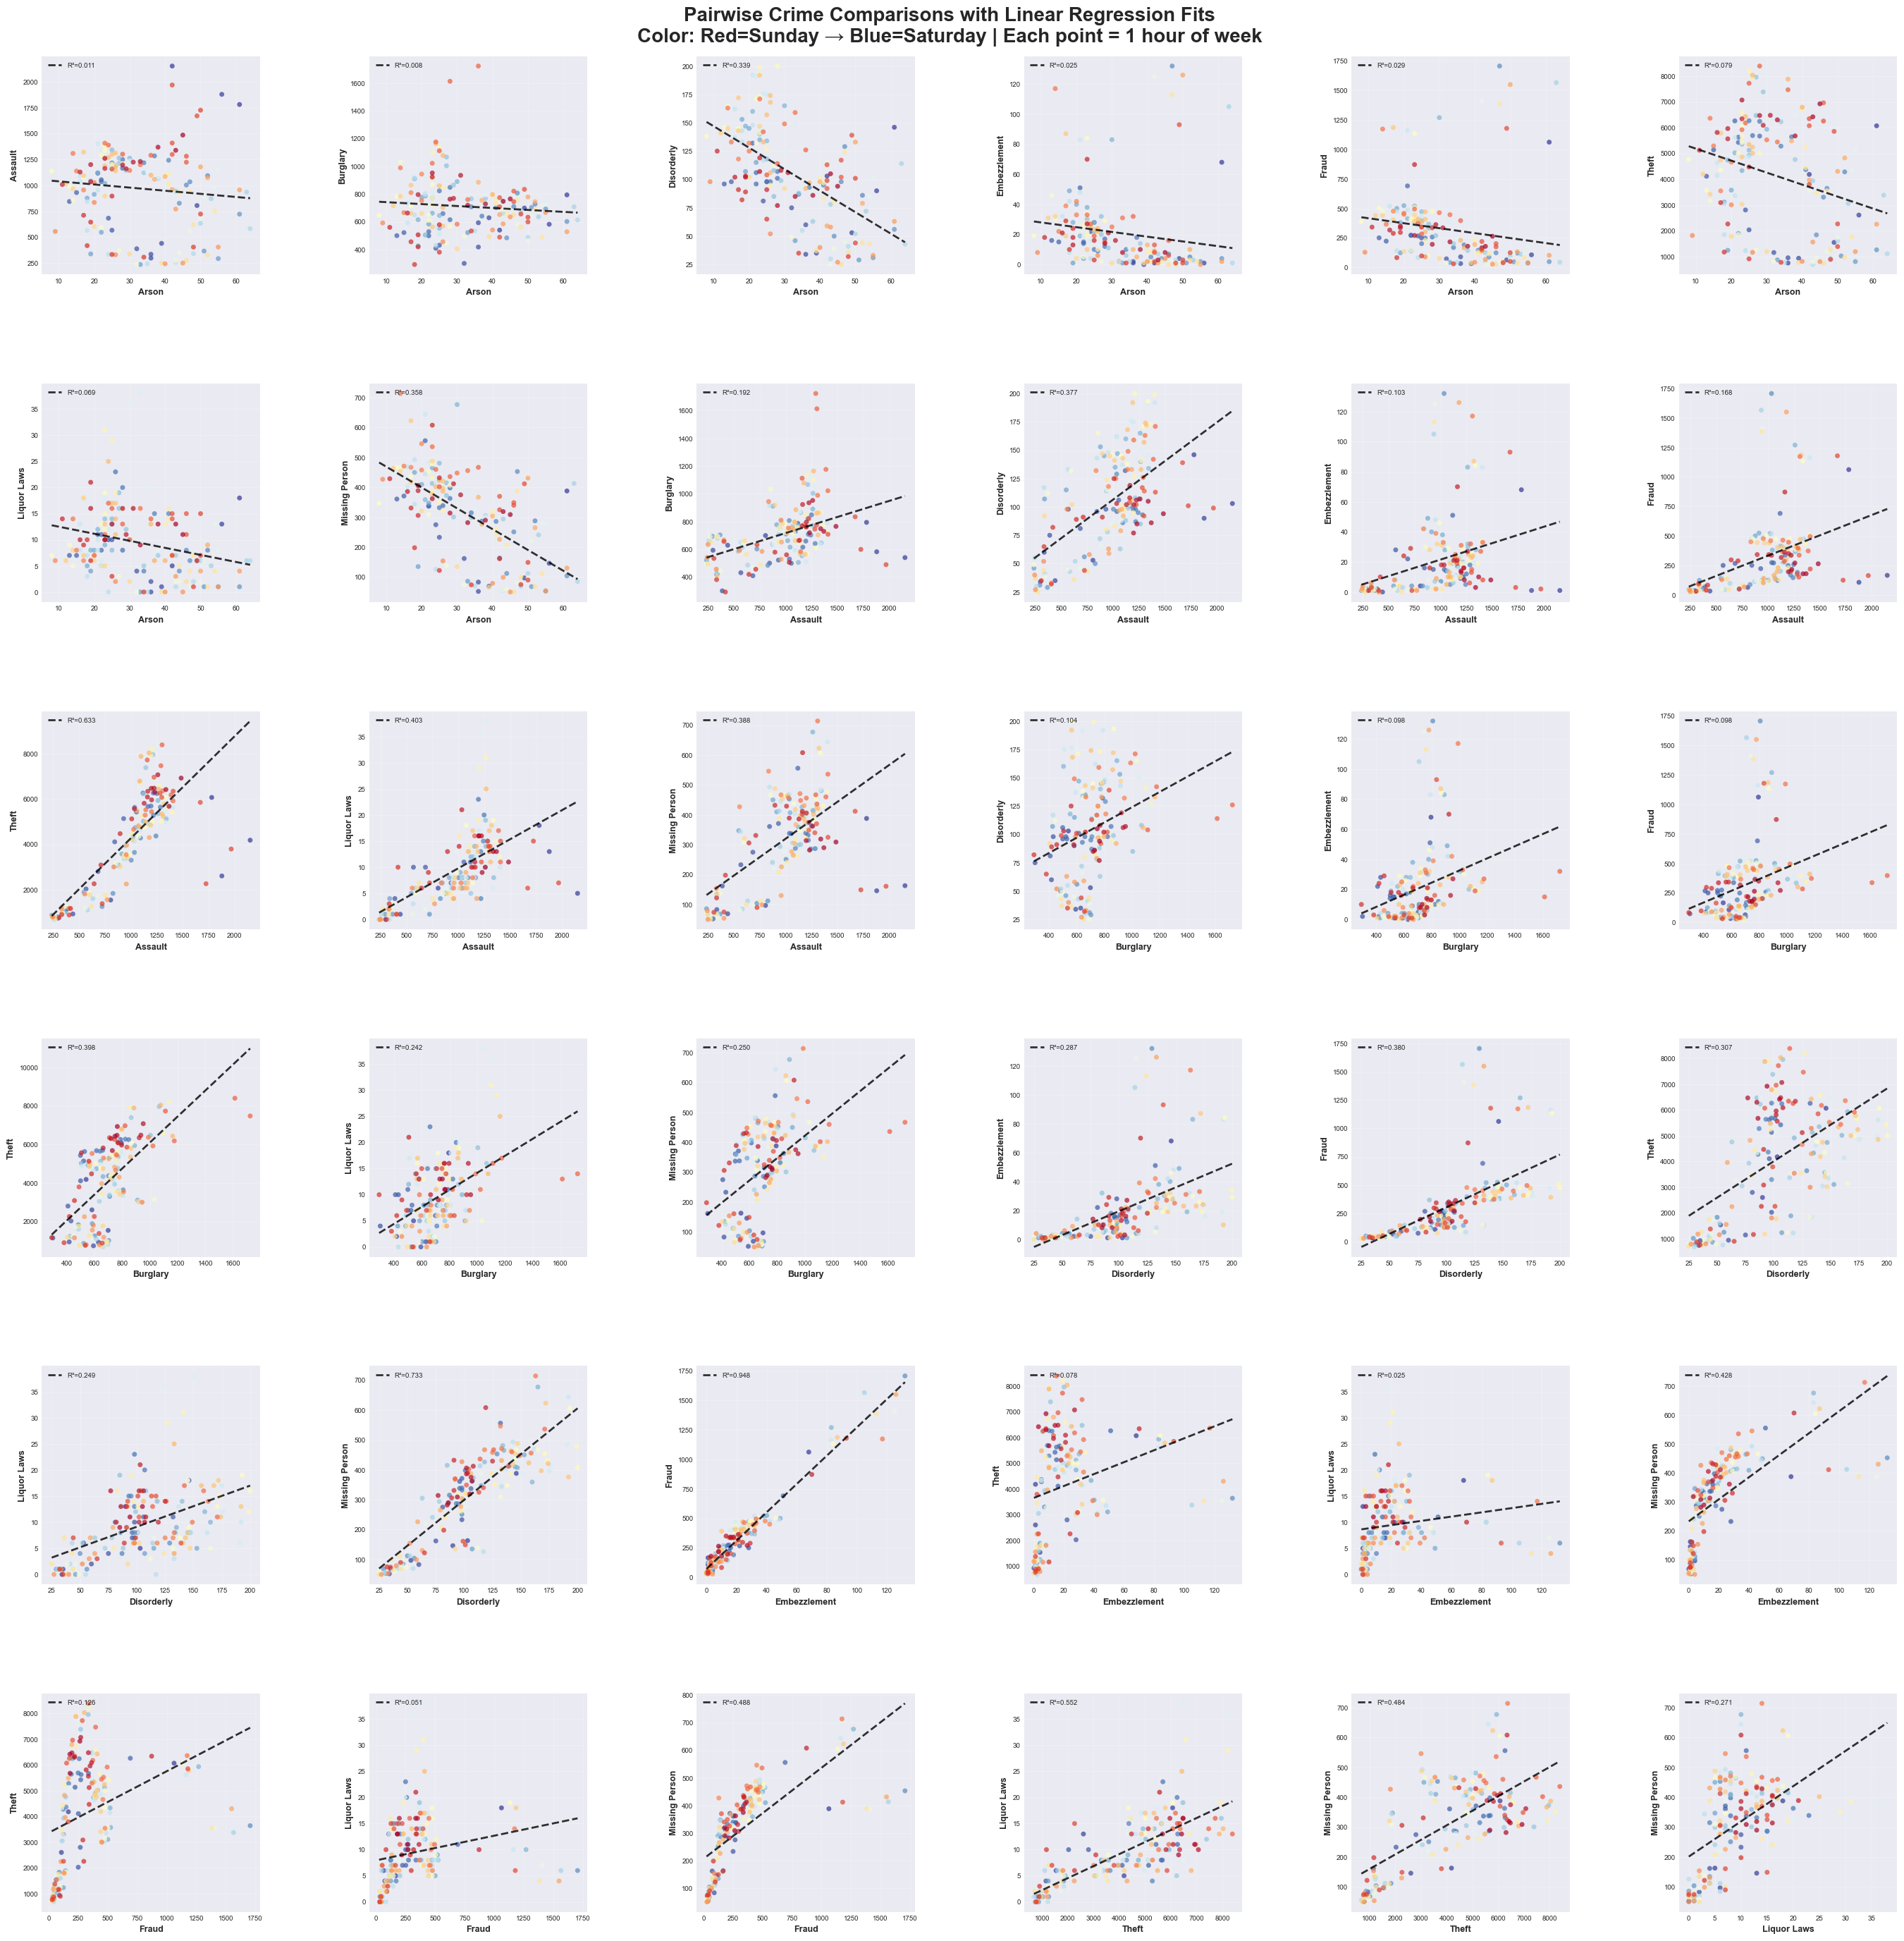

In [9]:
# Create color gradient: Red (Sunday) → Blue (Saturday)
colors = plt.cm.RdYlBu_r(np.linspace(0, 1, 168))

fig, axes = plt.subplots(6, 6, figsize=(28, 28))
fig.suptitle('Pairwise Crime Comparisons with Linear Regression Fits\n' +
             'Color: Red=Sunday → Blue=Saturday | Each point = 1 hour of week', 
             fontsize=20, fontweight='bold', y=0.995)

axes_flat = axes.flatten()

for idx, (crime1, crime2) in enumerate(crime_pairs):
    ax = axes_flat[idx]
    
    x = hourly_counts[crime1]
    y = hourly_counts[crime2]
    
    # Get regression results
    result = results_df[(results_df['crime1'] == crime1) & 
                        (results_df['crime2'] == crime2)].iloc[0]
    a = result['slope']
    b = result['intercept']
    r2 = result['r_squared']
    
    # Scatter plot with color gradient by hour
    for i in range(168):
        ax.scatter(x[i], y[i], color=colors[i], s=25, alpha=0.7, edgecolors='none')
    
    # Add regression line
    x_line = np.array([x.min(), x.max()])
    y_line = a * x_line + b
    ax.plot(x_line, y_line, 'k--', linewidth=2, alpha=0.8, label=f'R²={r2:.3f}')
    
    # Labels
    c1_short = crime1.replace('Larceny/Theft', 'Theft').replace('Disorderly Conduct', 'Disorderly')
    c2_short = crime2.replace('Larceny/Theft', 'Theft').replace('Disorderly Conduct', 'Disorderly')
    
    ax.set_xlabel(c1_short, fontsize=9, fontweight='bold')
    ax.set_ylabel(c2_short, fontsize=9, fontweight='bold')
    ax.tick_params(axis='both', labelsize=7)
    ax.legend(loc='upper left', fontsize=7)
    ax.grid(True, alpha=0.3, linewidth=0.5)

plt.subplots_adjust(left=0.04, right=0.98, top=0.97, bottom=0.03, hspace=0.5, wspace=0.5)
plt.savefig('crime_pairwise_with_regression.png', dpi=150, bbox_inches='tight')
print("✓ Saved: crime_pairwise_with_regression.png")
plt.show()

## Step 8: Verify R² = r² Connection

**Exercise 3.3 Part 2:** Explain the connection between R² and Pearson correlation

In [10]:
print("="*80)
print("EXERCISE 3.3: CONNECTION BETWEEN R² AND PEARSON CORRELATION")
print("="*80)

print("\nTheoretical relationship: R² = r²")
print("(For simple linear regression, R² equals the square of Pearson correlation)")

print("\nVerification with top 5 pairs:")
print("-" * 80)
for idx, row in results_sorted.head(5).iterrows():
    r_squared_calc = row['correlation'] ** 2
    print(f"{row['crime1']:20s} vs {row['crime2']:20s}")
    print(f"  R² (from formula) = {row['r_squared']:.6f}")
    print(f"  r² (correlation²) = {r_squared_calc:.6f}")
    print(f"  Difference        = {abs(row['r_squared'] - r_squared_calc):.10f}")
    print()

print("✓ Confirmed: R² = r² for simple linear regression!")

EXERCISE 3.3: CONNECTION BETWEEN R² AND PEARSON CORRELATION

Theoretical relationship: R² = r²
(For simple linear regression, R² equals the square of Pearson correlation)

Verification with top 5 pairs:
--------------------------------------------------------------------------------
Embezzlement         vs Fraud               
  R² (from formula) = 0.948361
  r² (correlation²) = 0.948361
  Difference        = 0.0000000000

Disorderly Conduct   vs Missing Person      
  R² (from formula) = 0.733155
  r² (correlation²) = 0.733155
  Difference        = 0.0000000000

Assault              vs Larceny/Theft       
  R² (from formula) = 0.632518
  r² (correlation²) = 0.632518
  Difference        = 0.0000000000

Larceny/Theft        vs Liquor Laws         
  R² (from formula) = 0.551971
  r² (correlation²) = 0.551971
  Difference        = 0.0000000000

Fraud                vs Missing Person      
  R² (from formula) = 0.487844
  r² (correlation²) = 0.487844
  Difference        = 0.0000000000

✓

## Step 9: Answer Key Questions

In [ ]:
most_similar = results_sorted.iloc[0]
most_dissimilar = results_sorted.iloc[-1]

print("="*80)
print("KEY FINDINGS")
print("="*80)

print("\n📊 MOST SIMILAR TEMPORAL PATTERN:")
print("-" * 80)
print(f"Crime Pair: {most_similar['crime1']} vs {most_similar['crime2']}")
print(f"R² = {most_similar['r_squared']:.4f}")
print(f"\nInterpretation: {most_similar['r_squared']*100:.1f}% of variance in {most_similar['crime2']}")
print(f"                is explained by {most_similar['crime1']}")

print("\n📊 MOST DISSIMILAR TEMPORAL PATTERN:")
print("-" * 80)
print(f"Crime Pair: {most_dissimilar['crime1']} vs {most_dissimilar['crime2']}")
print(f"R² = {most_dissimilar['r_squared']:.4f}")
print(f"\nInterpretation: Only {most_dissimilar['r_squared']*100:.1f}% of variance explained")
print(f"                These crimes follow very different weekly patterns")

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"  Highest R²: {results_sorted.iloc[0]['r_squared']:.4f}")
print(f"  Lowest R²:  {results_sorted.iloc[-1]['r_squared']:.4f}")
print(f"  Mean R²:    {results_df['r_squared'].mean():.4f}")
print(f"  Median R²:  {results_df['r_squared'].median():.4f}")

## Your Interpretation (Fill this in!)

### Question 1: Why do the most correlated crimes follow similar patterns?

**Your analysis:**

[Write your thoughts here about why these crimes might correlate - consider factors like:
- Time of day patterns
- Opportunity structures
- Shared contexts (nightlife, business hours, etc.)
- Victim/offender characteristics]

### Question 2: Why don't the uncorrelated crimes follow similar patterns?

**Your analysis:**

[Write your thoughts here about why these crimes differ - consider:
- Different reporting mechanisms
- Different contexts (street vs white-collar)
- Different times of occurrence
- Detection vs occurrence timing]

### Question 3: Connection to Week 1 - Predictive Policing

**Your reflection:**

[How do these findings relate to the predictive policing discussion from Week 1?
- What happens if a system uses correlated crime types?
- Could this create feedback loops?
- What are the implications for fairness and bias?]

## ✓ Exercises Complete!

You've successfully:
- ✓ Implemented linear regression from scratch (Exercise 3.2)
- ✓ Added regression lines to 36 scatterplots (Exercise 3.2)
- ✓ Color-coded points by hour of week (Exercise 3.2)
- ✓ Implemented R² calculation (Exercise 3.3)
- ✓ Verified R² = r² relationship (Exercise 3.3)
- ✓ Identified most/least similar crime pairs (Exercise 3.3)

**Generated files:**
- `crime_pairwise_with_regression.png`

**Next:** Connect these findings to the broader themes of data analysis and algorithmic accountability!